## Target Encoding 
### Replaces each category with the average value of the target variable for that category. This is a very predictive method but carries a high risk of overfitting, so it needs careful validation.

In [22]:
from sklearn.preprocessing import TargetEncoder
import pandas as pd

In [23]:
df = pd.DataFrame({
    'city': ['Vadodara', 'Gurugram', 'Noida', 'Mumbai', 'Chandigarh','Noida'],
    'price': [200, 150, 250, 300, 320, 280]
})

In [24]:
df

,city,price
0,Vadodara,200
1,Gurugram,150
2,Noida,250
3,Mumbai,300
4,Chandigarh,320
5,Noida,280


In [25]:
mean_price=df.groupby('city')['price'].mean().to_dict()

In [26]:
mean_price

{'Chandigarh': 320.0,
 'Gurugram': 150.0,
 'Mumbai': 300.0,
 'Noida': 265.0,
 'Vadodara': 200.0}

In [27]:
df['city_encoded'] = df['city'].map(mean_price)

In [28]:
df

,city,price,city_encoded
0,Vadodara,200,200.0
1,Gurugram,150,150.0
2,Noida,250,265.0
3,Mumbai,300,300.0
4,Chandigarh,320,320.0
5,Noida,280,265.0


In [29]:
df[['price','city_encoded']]

,price,city_encoded
0,200,200.0
1,150,150.0
2,250,265.0
3,300,300.0
4,320,320.0
5,280,265.0


## Practice Assignment

### As an exercise, import the seaborn library and load the tips dataset. Try applying target guided ordinal encoding to the time categorical feature based on the total_bill target variable.

In [32]:
import seaborn as sns
df = sns.load_dataset('tips')

In [33]:
df

,total_bill,tip,sex,smoker,day,time,size
0,16.99,1.01,Female,No,Sun,Dinner,2
1,10.34,1.66,Male,No,Sun,Dinner,3
2,21.01,3.50,Male,No,Sun,Dinner,3
3,23.68,3.31,Male,No,Sun,Dinner,2
4,24.59,3.61,Female,No,Sun,Dinner,4
...,...,...,...,...,...,...,...
239,29.03,5.92,Male,No,Sat,Dinner,3
240,27.18,2.00,Female,Yes,Sat,Dinner,2
241,22.67,2.00,Male,Yes,Sat,Dinner,2
242,17.82,1.75,Male,No,Sat,Dinner,2


In [34]:
df.head()

,total_bill,tip,sex,smoker,day,time,size
0,16.99,1.01,Female,No,Sun,Dinner,2
1,10.34,1.66,Male,No,Sun,Dinner,3
2,21.01,3.50,Male,No,Sun,Dinner,3
3,23.68,3.31,Male,No,Sun,Dinner,2
4,24.59,3.61,Female,No,Sun,Dinner,4


In [35]:
df[['time','total_bill']]

,time,total_bill
0,Dinner,16.99
1,Dinner,10.34
2,Dinner,21.01
3,Dinner,23.68
4,Dinner,24.59
...,...,...
239,Dinner,29.03
240,Dinner,27.18
241,Dinner,22.67
242,Dinner,17.82


In [41]:
mean_time=df.groupby('time', observed=True)['total_bill'].mean().to_dict()
median_time=df.groupby('time', observed=True)['total_bill'].median().to_dict()

In [42]:
mean_time

{'Lunch': 17.168676470588235, 'Dinner': 20.79715909090909}

In [43]:
median_time

{'Lunch': 15.965, 'Dinner': 18.39}

In [44]:
df['mean_total_bill_and_time'] = df['time'].map(mean_time)

In [47]:
df[['time','mean_total_bill_and_time','total_bill']]

,time,mean_total_bill_and_time,total_bill
0,Dinner,20.797159,16.99
1,Dinner,20.797159,10.34
2,Dinner,20.797159,21.01
3,Dinner,20.797159,23.68
4,Dinner,20.797159,24.59
...,...,...,...
239,Dinner,20.797159,29.03
240,Dinner,20.797159,27.18
241,Dinner,20.797159,22.67
242,Dinner,20.797159,17.82


In [48]:
df['median_total_bill_and_time'] = df['time'].map(median_time)

In [49]:
df[['time','median_total_bill_and_time','total_bill']]

,time,median_total_bill_and_time,total_bill
0,Dinner,18.39,16.99
1,Dinner,18.39,10.34
2,Dinner,18.39,21.01
3,Dinner,18.39,23.68
4,Dinner,18.39,24.59
...,...,...,...
239,Dinner,18.39,29.03
240,Dinner,18.39,27.18
241,Dinner,18.39,22.67
242,Dinner,18.39,17.82


<Axes: xlabel='total_bill', ylabel='Count'>

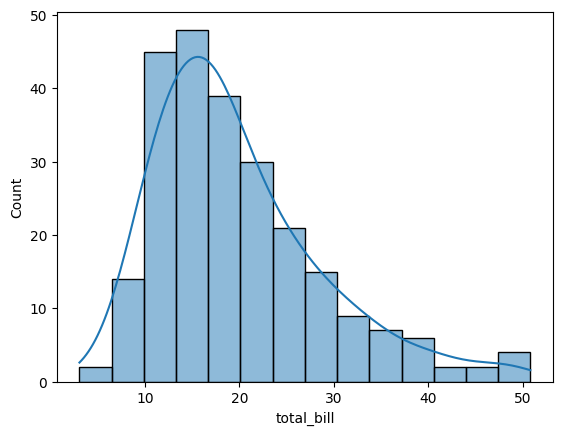

In [51]:
sns.histplot(df['total_bill'],kde=True)

<Axes: xlabel='mean_total_bill_and_time', ylabel='Count'>

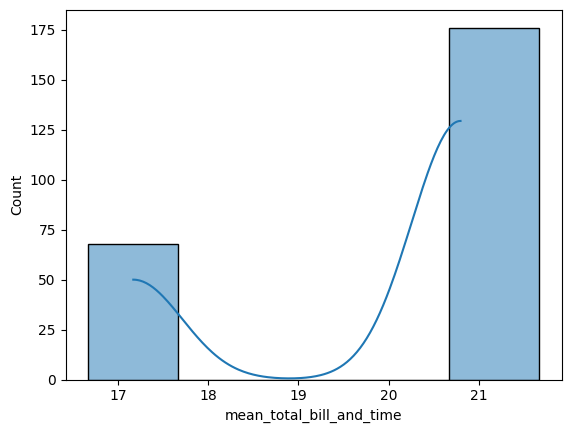

In [52]:
sns.histplot(df['mean_total_bill_and_time'],kde=True)

<Axes: xlabel='median_total_bill_and_time', ylabel='Count'>

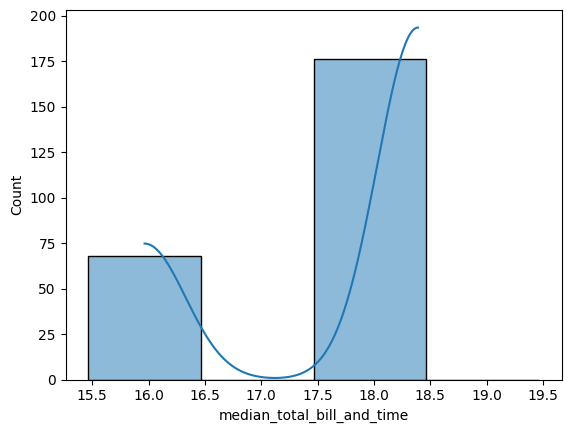

In [53]:
sns.histplot(df['median_total_bill_and_time'],kde=True)

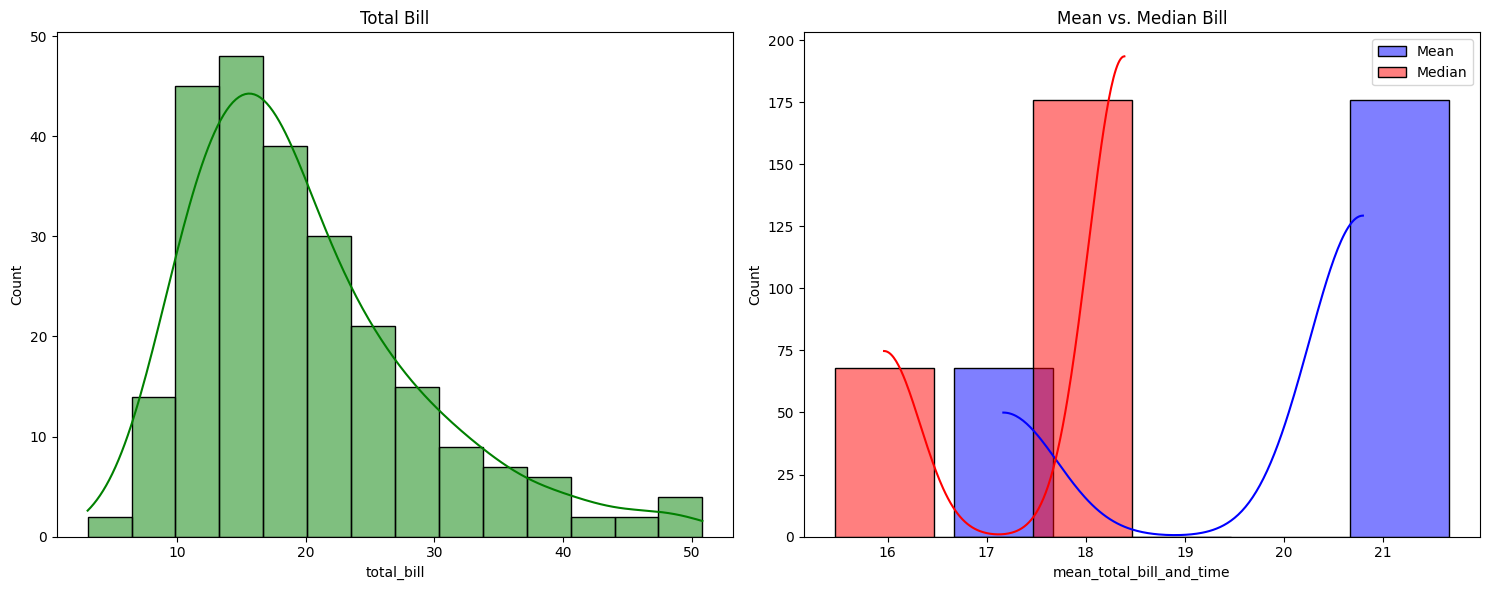

In [ ]:
import seaborn as sns
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np

# ax1 will be the first plot, ax2 will be the second plot
fig, (ax1, ax2) = plt.subplots(nrows=1, ncols=2, figsize=(15, 6))


# Plot the 'total_bill' on the first axes (ax1)
sns.histplot(df['total_bill'], kde=True, ax=ax1, color='green')
ax1.set_title('Total Bill')


# Plot the 'mean' and 'median' on the second axes (ax2)
sns.histplot(df['mean_total_bill_and_time'], kde=True, ax=ax2, color='blue', label='Mean')
sns.histplot(df['median_total_bill_and_time'], kde=True, ax=ax2, color='red', label='Median')
ax2.set_title('Mean vs. Median Bill')
ax2.legend()

plt.tight_layout()
plt.show()

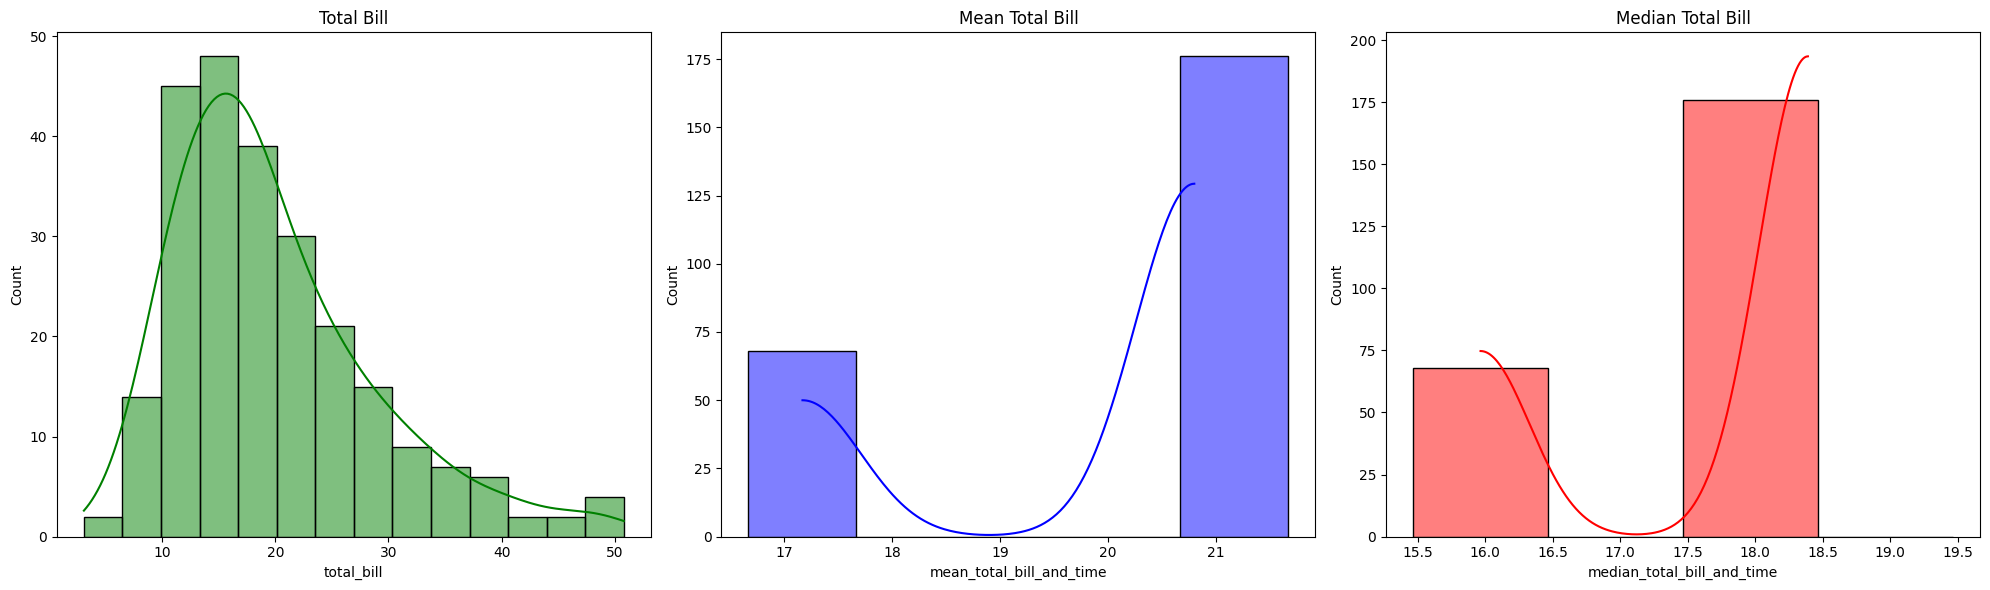

In [ ]:
fig, (ax1, ax2, ax3) = plt.subplots(nrows=1, ncols=3, figsize=(20, 6))


sns.histplot(df['total_bill'], kde=True, ax=ax1, color='green')
ax1.set_title('Total Bill')


sns.histplot(df['mean_total_bill_and_time'], kde=True, ax=ax2, color='blue')
ax2.set_title('Mean Total Bill')


sns.histplot(df['median_total_bill_and_time'], kde=True, ax=ax3, color='red')
ax3.set_title('Median Total Bill')


plt.tight_layout()
plt.show()